# A Four-Step Travel Demand Model for Milan

The classical **four-step model** — the workhorse of transportation planning — built
end-to-end **on real, open data**:

1. **Trip generation** — how many trips does each zone produce and attract?
2. **Trip distribution** — which origins connect to which destinations? (gravity model)
3. **Mode choice** — car or public transport? (binary logit on **real GTFS transit times**)
4. **Trip assignment** — which streets carry the trips? (**user equilibrium via MSA**, not
   just all-or-nothing)

Data: Milan's major-road network and boundary from **OpenStreetMap**, the official
**GTFS feed** of Milan's public transport (published by the Comune di Milano / AMAT for
the ATM network), land use proxied from OSM residential areas and workplaces. Everything
downloads at run time — fully reproducible.

Then the model earns its keep with a **policy scenario**: banning through car traffic from
the inner cordon (an Area-C-style measure) and mapping where those trips relocate. Plus the
practitioner staples: **select-link analysis**, skim matrices, and interactive web maps.

> **Honesty note.** Trip rates, deterrence and logit parameters, BPR coefficients, and the
> population/jobs control totals are stated assumptions — not values calibrated against
> Milanese surveys and counts. The machinery is the point. I have applied this same
> workflow to a real metropolitan planning model (~58,000 links, 2030/2040 scenarios);
> that dataset is not distributable, hence this open-data rebuild.

## 1. Milan's boundary and major-road network (OpenStreetMap)

Major drivable roads (motorway → tertiary), largest strongly connected component, with
**assumed** free-flow speeds and hourly capacities per road class.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True
CRS_UTM = "EPSG:32632"                      # UTM 32N — Milan

milan = ox.geocode_to_gdf("Milan, Lombardy, Italy")
boundary = milan.geometry.iloc[0]
print(f"boundary area: {milan.to_crs(CRS_UTM).area.iloc[0] / 1e6:.0f} km2")

boundary area: 182 km2


In [2]:
MAJOR = ('["highway"~"motorway|trunk|primary|secondary|tertiary'
         '|motorway_link|trunk_link|primary_link|secondary_link"]')
G_raw = ox.graph_from_polygon(boundary, network_type="drive",
                              custom_filter=MAJOR, retain_all=True)
scc = max(nx.strongly_connected_components(G_raw), key=len)
G_osm = ox.project_graph(G_raw.subgraph(scc).copy(), to_crs=CRS_UTM)

SPEED_KMH = {"motorway": 90, "trunk": 70, "primary": 50, "secondary": 40,
             "tertiary": 30, "motorway_link": 60, "trunk_link": 50,
             "primary_link": 40, "secondary_link": 30}
CAPACITY = {"motorway": 4000, "trunk": 3000, "primary": 1600, "secondary": 1200,
            "tertiary": 800, "motorway_link": 1500, "trunk_link": 1200,
            "primary_link": 800, "secondary_link": 600}

def road_class(hwy):
    h = hwy[0] if isinstance(hwy, list) else hwy
    return h if h in SPEED_KMH else "tertiary"

for u, v, k, d in G_osm.edges(keys=True, data=True):
    cls = road_class(d.get("highway", "tertiary"))
    d["cls"] = cls
    d["time_min"] = d["length"] / 1000 / SPEED_KMH[cls] * 60
    d["capacity"] = CAPACITY[cls]

print(f"network: {G_osm.number_of_nodes():,} nodes, {G_osm.number_of_edges():,} edges")

network: 2,963 nodes, 5,187 edges


### A compressed edge representation for fast assignment

Repeated shortest-path passes (equilibrium needs ~a dozen) would crawl in pure NetworkX,
so the network is compressed once into SciPy sparse-matrix form. Parallel edges between the
same node pair are collapsed to the fastest one.

In [3]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

node_ids = np.array(list(G_osm.nodes))
idx_of = {n: i for i, n in enumerate(node_ids)}
node_xy = np.array([[G_osm.nodes[n]["x"], G_osm.nodes[n]["y"]] for n in node_ids])
NN = len(node_ids)

best = {}
for u, v, k, d in G_osm.edges(keys=True, data=True):
    key = (idx_of[u], idx_of[v])
    if key not in best or d["time_min"] < best[key]["time_min"]:
        best[key] = {"time_min": d["time_min"], "capacity": d["capacity"],
                     "cls": d["cls"], "length": d["length"], "key": k, "u": u, "v": v}

E = len(best)
e_from = np.fromiter((k[0] for k in best), int, E)
e_to = np.fromiter((k[1] for k in best), int, E)
e_t0 = np.fromiter((d["time_min"] for d in best.values()), float, E)
e_cap = np.fromiter((d["capacity"] for d in best.values()), float, E)
e_cls = np.array([d["cls"] for d in best.values()])
edge_index = {k: i for i, k in enumerate(best)}       # (ui, vi) -> edge row

geoms = ox.graph_to_gdfs(G_osm, nodes=False)
e_geom = [geoms.loc[(d["u"], d["v"], d["key"])].geometry for d in best.values()]
edges_net = gpd.GeoDataFrame(
    {"cls": e_cls, "t0_min": e_t0, "capacity": e_cap}, geometry=e_geom, crs=CRS_UTM)

def graph_matrix(times):
    return csr_matrix((times, (e_from, e_to)), shape=(NN, NN))

print(f"{E:,} unique directed links")

5,148 unique directed links


## 2. Zones and land use

A ~1.2 km hexagonal zone grid clipped to the boundary. Population ∝ OSM
`landuse=residential` area (scaled to an assumed 1.4 M residents); jobs ∝ OSM workplace
features (scaled to an assumed 900 k workplaces).

In [4]:
from shapely.geometry import Polygon

boundary_utm = gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(CRS_UTM).iloc[0]
minx, miny, maxx, maxy = boundary_utm.bounds
R = 700.0
dx, dy = 1.5 * R, np.sqrt(3) * R
hexes, ix = [], 0
x = minx - R
while x < maxx + R:
    y = miny - R - (dy / 2 if ix % 2 else 0)
    while y < maxy + R:
        hexes.append(Polygon([(x + R * np.cos(a), y + R * np.sin(a))
                              for a in np.linspace(0, 2 * np.pi, 7)[:-1]]))
        y += dy
    x += dx
    ix += 1
grid = gpd.GeoDataFrame(geometry=hexes, crs=CRS_UTM)
grid = grid[grid.intersects(boundary_utm)].copy()
grid["geometry"] = grid.geometry.intersection(boundary_utm)
grid = grid[grid.area > 0.15 * (1.5 * np.sqrt(3) * R * R)].reset_index(drop=True)
grid["Z"] = grid.index + 1
print(f"{len(grid)} zones")

163 zones


In [5]:
residential = ox.features_from_polygon(boundary, {"landuse": ["residential"]})
residential = residential[residential.geometry.geom_type.isin(
    ["Polygon", "MultiPolygon"])].to_crs(CRS_UTM)
res_union = residential.geometry.union_all()
grid["res_area"] = grid.geometry.intersection(res_union).area

jobs_feats = ox.features_from_polygon(
    boundary, {"office": True, "shop": True, "industrial": True,
               "amenity": ["school", "university", "hospital", "restaurant",
                           "cafe", "bank", "pharmacy"]})
jobs_pts = jobs_feats.to_crs(CRS_UTM).copy()
jobs_pts["geometry"] = jobs_pts.geometry.centroid
joined = gpd.sjoin(jobs_pts[["geometry"]], grid[["Z", "geometry"]],
                   how="inner", predicate="within")
grid["poi_count"] = grid["Z"].map(joined.groupby("Z").size()).fillna(0)

TOTAL_POP, TOTAL_JOBS = 1_400_000, 900_000     # assumed control totals
grid["population"] = grid["res_area"] / grid["res_area"].sum() * TOTAL_POP
grid["jobs"] = grid["poi_count"] / grid["poi_count"].sum() * TOTAL_JOBS
print(f"{len(residential):,} residential polygons | {len(jobs_pts):,} workplace features")

989 residential polygons | 17,191 workplace features


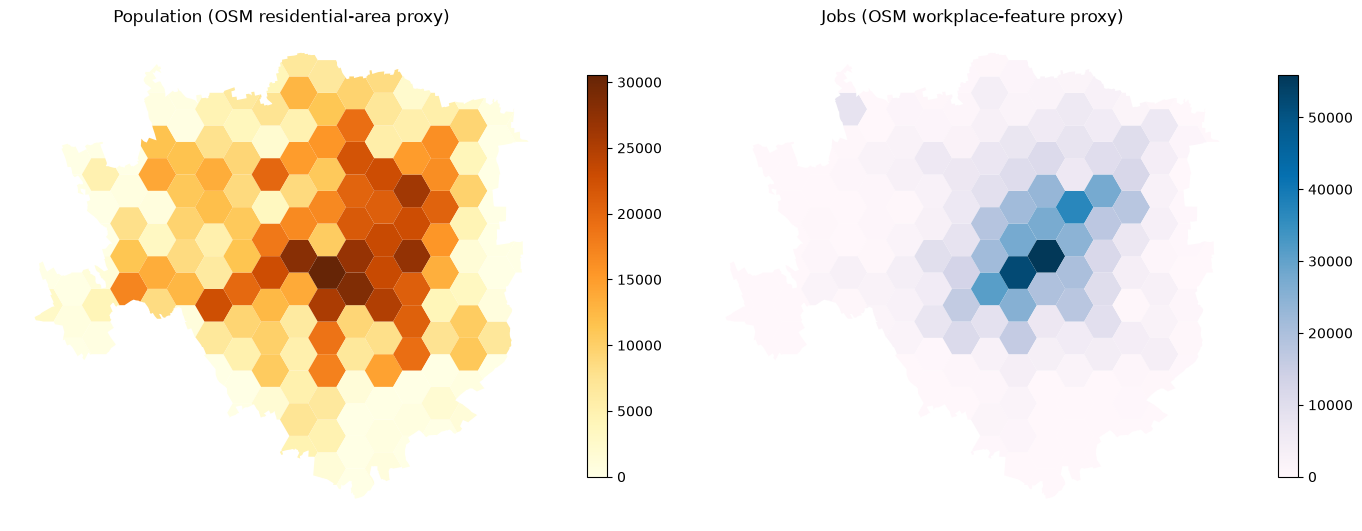

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
grid.plot(column="population", ax=axes[0], cmap="YlOrBr", legend=True,
          legend_kwds={"shrink": 0.6})
axes[0].set_title("Population (OSM residential-area proxy)")
grid.plot(column="jobs", ax=axes[1], cmap="PuBu", legend=True,
          legend_kwds={"shrink": 0.6})
axes[1].set_title("Jobs (OSM workplace-feature proxy)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 3. Step 1 — Trip generation, and car skims

Morning-peak rates on population and jobs, attractions balanced to productions. Car skims
are one multi-source Dijkstra over the compressed network.

In [7]:
P_RATE, A_RATE = 0.32, 0.55
grid["productions"] = grid["population"] * P_RATE
grid["attractions"] = grid["jobs"] * A_RATE
grid["attractions"] *= grid["productions"].sum() / grid["attractions"].sum()

cent = grid.geometry.centroid
def nearest_net_node(p):
    return int(np.argmin(np.hypot(node_xy[:, 0] - p.x, node_xy[:, 1] - p.y)))
grid["net_node"] = [nearest_net_node(p) for p in cent]
grid["access_min"] = [
    float(np.hypot(*(node_xy[n] - (p.x, p.y))) / 1000 / 20 * 60)
    for n, p in zip(grid["net_node"], cent)]

Z = len(grid)
sources = grid["net_node"].to_numpy()
acc = grid["access_min"].to_numpy()

D = dijkstra(graph_matrix(e_t0), indices=sources)
car_skim = D[:, sources] + acc[:, None] + acc[None, :]
np.fill_diagonal(car_skim, 3.0)
print(f"{grid['productions'].sum():,.0f} peak trips | "
      f"car skim mean {car_skim[np.isfinite(car_skim)].mean():.1f} min")

448,000 peak trips | car skim mean 16.2 min


## 4. Step 2 — Trip distribution (doubly-constrained gravity model)

$T_{ij} = a_i b_j P_i A_j e^{-\beta t_{ij}}$ with Furness/IPF balancing.

In [8]:
BETA = 0.10
finite = np.isfinite(car_skim)
F = np.where(finite, np.exp(-BETA * car_skim), 0.0)
P = grid["productions"].to_numpy()
A = grid["attractions"].to_numpy()
T = np.outer(P, A) * F
for it in range(60):
    T *= (P / np.maximum(T.sum(axis=1), 1e-9))[:, None]
    T *= (A / np.maximum(T.sum(axis=0), 1e-9))[None, :]
    if max(np.abs(T.sum(axis=1) - P).max(),
           np.abs(T.sum(axis=0) - A).max()) < 1.0:
        break
print(f"converged in {it + 1} iterations | mean trip time "
      f"{(T * np.where(finite, car_skim, 0)).sum() / T.sum():.1f} min")

converged in 3 iterations | mean trip time 10.2 min


## 5. Real public-transport times from the official GTFS feed

Milan's GTFS (published on the [Comune di Milano open-data portal](https://dati.comune.milano.it/dataset/ds929-orari-del-trasporto-pubblico-locale-nel-comune-di-milano-in-formato-gtfs),
produced by AMAT from ATM's scheduled service) drives a **frequency-based transit graph**:

- one *route node* per (route, direction, stop) with **boarding edges** costing half the
  AM-peak headway (capped at 15 min);
- **riding edges** between consecutive stops using scheduled in-vehicle times;
- **alighting edges** (0.5 min) and **walking transfers** between stops within 250 m;
- zone centroids connect to their nearby stops by walking.

This is the standard aggregated alternative to timetable routing (RAPTOR-style), and it
prices transfers properly because every boarding pays that route's expected wait.

In [9]:
import io, zipfile
from pathlib import Path
from urllib.request import urlretrieve

GTFS_URL = "https://dati.comune.milano.it/gtfs.zip"
gtfs_path = Path("cache/milan_gtfs.zip")
gtfs_path.parent.mkdir(exist_ok=True)
if not gtfs_path.exists():
    urlretrieve(GTFS_URL, gtfs_path)
zf = zipfile.ZipFile(gtfs_path)

stops = pd.read_csv(zf.open("stops.txt"),
                    usecols=["stop_id", "stop_lat", "stop_lon"])
trips = pd.read_csv(zf.open("trips.txt"),
                    usecols=["route_id", "trip_id", "direction_id"])
stop_times = pd.read_csv(
    zf.open("stop_times.txt"),
    usecols=["trip_id", "arrival_time", "stop_id", "stop_sequence"],
    dtype={"trip_id": str, "arrival_time": str, "stop_id": str})
print(f"GTFS: {len(stops):,} stops, {len(trips):,} trips, "
      f"{len(stop_times):,} stop_times rows")

GTFS: 4,902 stops, 127,750 trips, 2,999,855 stop_times rows


In [10]:
def to_seconds(s):
    h, m, sec = s.split(":")
    return int(h) * 3600 + int(m) * 60 + int(sec)

stop_times["sec"] = stop_times["arrival_time"].map(to_seconds)

# AM peak window 07:00-09:00: keep trips whose first stop departs in-window
first = stop_times.sort_values("stop_sequence").groupby("trip_id")["sec"].first()
peak_trips = first[(first >= 7 * 3600) & (first < 9 * 3600)].index
st = stop_times[stop_times["trip_id"].isin(peak_trips)].merge(
    trips, on="trip_id")
st["direction_id"] = st["direction_id"].fillna(0).astype(int)
print(f"{len(peak_trips):,} AM-peak trips over "
      f"{st['route_id'].nunique():,} routes")

17,819 AM-peak trips over 141 routes


In [11]:
# headway per (route, direction) from peak-trip counts; wait = headway/2, capped
counts = st.groupby(["route_id", "direction_id"])["trip_id"].nunique()
headway_min = (120 / counts).clip(lower=2)
wait_min = (headway_min / 2).clip(upper=15)

# representative trip per (route, direction): the one serving the most stops
st_sorted = st.sort_values(["trip_id", "stop_sequence"])
trip_len = st_sorted.groupby(["route_id", "direction_id", "trip_id"]).size()
rep_trips = trip_len.reset_index(name="n").sort_values("n").groupby(
    ["route_id", "direction_id"]).tail(1)["trip_id"]
rep = st_sorted[st_sorted["trip_id"].isin(rep_trips)]
print(f"{len(rep_trips):,} representative route-direction patterns")

260 representative route-direction patterns


In [12]:
# ---- assemble the frequency-based graph as an edge list of string nodes ----
pt_edges = []          # (from_node, to_node, minutes)
used_stops = set()

for (route, dirn, trip), g in rep.groupby(["route_id", "direction_id", "trip_id"]):
    w = float(wait_min.loc[(route, dirn)])
    g = g.sort_values("stop_sequence")
    sids = g["stop_id"].tolist()
    secs = g["sec"].tolist()
    for s in sids:
        used_stops.add(s)
        rn = f"r|{route}|{dirn}|{s}"
        pt_edges.append((f"s|{s}", rn, w))          # board: expected wait
        pt_edges.append((rn, f"s|{s}", 0.5))        # alight
    for (s1, t1), (s2, t2) in zip(zip(sids[:-1], secs[:-1]),
                                  zip(sids[1:], secs[1:])):
        ivt = max((t2 - t1) / 60, 0.3)
        pt_edges.append((f"r|{route}|{dirn}|{s1}", f"r|{route}|{dirn}|{s2}", ivt))

stops_used = stops[stops["stop_id"].astype(str).isin(used_stops)].copy()
stops_gdf = gpd.GeoDataFrame(
    stops_used, geometry=gpd.points_from_xy(stops_used["stop_lon"],
                                            stops_used["stop_lat"]),
    crs="EPSG:4326").to_crs(CRS_UTM)
print(f"{len(stops_gdf):,} stops in service, {len(pt_edges):,} transit edges")

4,410 stops in service, 18,919 transit edges


In [13]:
# walking transfers between stops within 250 m (4.5 km/h + 2 min penalty)
sxy = np.array([[p.x, p.y] for p in stops_gdf.geometry])
sid = stops_gdf["stop_id"].astype(str).to_numpy()
buf = gpd.GeoDataFrame(geometry=stops_gdf.geometry.buffer(250), crs=CRS_UTM)
pairs = stops_gdf.sindex.query(buf.geometry, predicate="intersects")
for a, b in zip(*pairs):
    if a >= b:
        continue
    dist = float(np.hypot(*(sxy[a] - sxy[b])))
    walk = dist / 1000 / 4.5 * 60 + 2.0
    pt_edges.append((f"s|{sid[a]}", f"s|{sid[b]}", walk))
    pt_edges.append((f"s|{sid[b]}", f"s|{sid[a]}", walk))

# zone access/egress: centroid walks to every stop within 900 m
zc = np.array([[p.x, p.y] for p in cent])
buf_z = gpd.GeoDataFrame(geometry=gpd.GeoSeries(cent, crs=CRS_UTM).buffer(900),
                         crs=CRS_UTM)
zp = stops_gdf.sindex.query(buf_z.geometry, predicate="intersects")
n_access = 0
for zi, si in zip(*zp):
    walk = float(np.hypot(*(zc[zi] - sxy[si]))) / 1000 / 4.5 * 60
    pt_edges.append((f"z|{zi}", f"s|{sid[si]}", walk))
    pt_edges.append((f"s|{sid[si]}", f"z|{zi}", walk))
    n_access += 1
print(f"transfer+access edges added | {n_access:,} zone-stop connectors")

transfer+access edges added | 6,376 zone-stop connectors


In [14]:
# compress to a sparse matrix and skim all zones at once
pt_nodes = sorted({n for e in pt_edges for n in e[:2]})
pt_idx = {n: i for i, n in enumerate(pt_nodes)}
pf = np.array([pt_idx[a] for a, b, w in pt_edges])
pt_ = np.array([pt_idx[b] for a, b, w in pt_edges])
pw = np.array([w for a, b, w in pt_edges])
# duplicate (from,to) pairs are fine: csr_matrix sums them, so keep the min instead
order = np.lexsort((pw, pt_, pf))
pf, pt_, pw = pf[order], pt_[order], pw[order]
keep = np.r_[True, (np.diff(pf) != 0) | (np.diff(pt_) != 0)]
M_pt = csr_matrix((pw[keep], (pf[keep], pt_[keep])),
                  shape=(len(pt_nodes), len(pt_nodes)))

z_rows = np.array([pt_idx.get(f"z|{i}", -1) for i in range(Z)])
ok = z_rows >= 0
pt_skim = np.full((Z, Z), np.inf)
Dp = dijkstra(M_pt, indices=z_rows[ok])
pt_skim[np.ix_(ok, ok)] = Dp[:, z_rows[ok]]
np.fill_diagonal(pt_skim, 5.0)
reach = np.isfinite(pt_skim).mean()
ratio = np.nanmedian(np.where(finite & np.isfinite(pt_skim),
                              pt_skim / car_skim, np.nan))
print(f"PT skim: {reach:.0%} of OD pairs reachable | "
      f"median PT/car time ratio {ratio:.2f}")

PT skim: 90% of OD pairs reachable | median PT/car time ratio 3.37


## 6. Step 3 — Mode choice (binary logit on real times)

Car versus public transport, now with **scheduled** PT door-to-door times:
$P_{car} = e^{V_{car}} / (e^{V_{car}} + e^{V_{pt}})$. Where PT can't serve a pair, the
trips go to car.

In [15]:
V_car = -0.055 * car_skim - 1.4          # constant covers parking/cost in the core
V_pt = np.where(np.isfinite(pt_skim), -0.055 * pt_skim, -np.inf)
with np.errstate(over="ignore", invalid="ignore"):
    p_car = 1 / (1 + np.exp(V_pt - V_car))
p_car = np.where(np.isfinite(pt_skim), p_car, 1.0)
T_car = np.where(finite, T * p_car, 0)
T_pt = np.where(finite, T * (1 - p_car), 0)
print(f"car share {T_car.sum() / T.sum():.1%} | PT share {T_pt.sum() / T.sum():.1%}")

car share 45.9% | PT share 54.1%


## 7. Step 4 — Assignment: from all-or-nothing to user equilibrium

All-or-nothing ignores congestion. Here the loop is closed with the **Method of
Successive Averages**: assign on congested times, average the flows in, update times with
the **BPR** volume-delay function $t = t_0\,(1 + 0.15\,(v/c)^4)$, repeat. The relative
gap measures how far flows are from Wardrop user equilibrium.

Two housekeeping assumptions first: the demand model covers the whole ~2-hour morning
peak while capacities are hourly, so an assumed **peak-hour factor of 0.45** converts the
matrix to the modelled hour. And with only major roads in the network, local traffic that
would use minor streets is absent - read v/c ratios as indicative.

In [16]:
def aon_assign(times, demand):
    """All-or-nothing: assign demand on shortest paths under `times`.
    Returns per-edge flows, using predecessor trees from SciPy."""
    flows = np.zeros(E)
    Dm, Pr = dijkstra(graph_matrix(times), indices=sources,
                      return_predecessors=True)
    for i in range(Z):
        pred = Pr[i]
        for j in range(Z):
            f = demand[i, j]
            if i == j or f < 1e-6:
                continue
            b = sources[j]
            while b != sources[i]:
                a = pred[b]
                if a < 0:
                    break
                flows[edge_index[(a, b)]] += f
                b = a
    return flows

def bpr(t0, v, c):
    return t0 * (1 + 0.15 * (v / c) ** 4)

def msa_equilibrium(demand, n_iter=18):
    v = aon_assign(e_t0, demand)
    gaps = []
    for k in range(2, n_iter + 1):
        t_cong = bpr(e_t0, v, e_cap)
        y = aon_assign(t_cong, demand)
        gap = abs((v - y) @ t_cong) / max(y @ t_cong, 1e-9)
        gaps.append(gap)
        v = v + (y - v) / k
    return v, bpr(e_t0, v, e_cap), gaps

PHF = 0.45          # assumed share of the 2h-peak demand in the modelled hour
T_asn = T_car * PHF

flow_aon = aon_assign(e_t0, T_asn)
flow_eq, t_eq, gaps = msa_equilibrium(T_asn)
print(f"relative gap: {gaps[0]:.3f} -> {gaps[-1]:.3f} over {len(gaps)} iterations")

relative gap: 4.883 -> 0.043 over 17 iterations


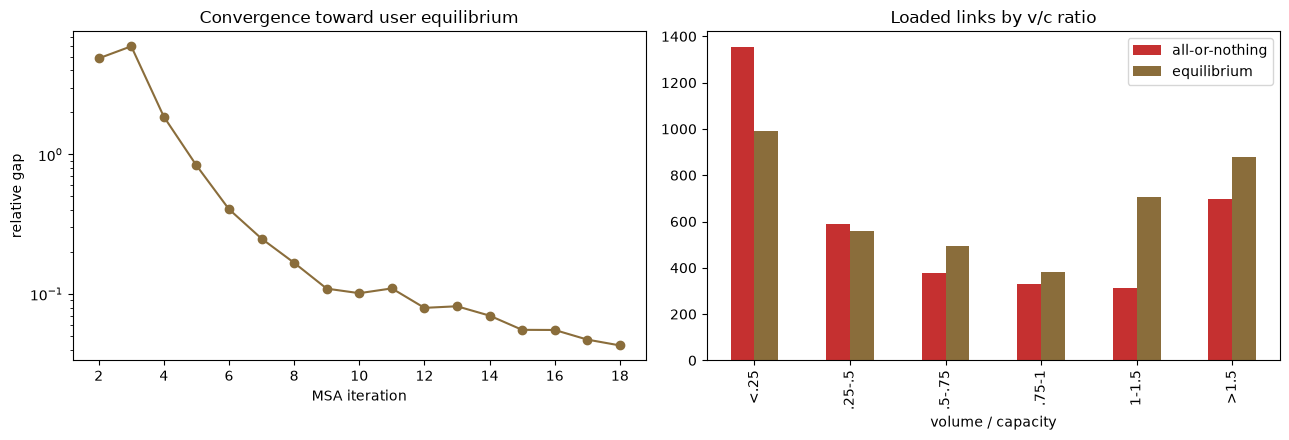

links over capacity: AON 1012 -> equilibrium 1585


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(2, len(gaps) + 2), gaps, marker="o", color="#8a6d3b")
axes[0].set_yscale("log"); axes[0].set_xlabel("MSA iteration")
axes[0].set_ylabel("relative gap"); axes[0].set_title("Convergence toward user equilibrium")

vc_aon = flow_aon / e_cap
vc_eq = flow_eq / e_cap
bins = [0, .25, .5, .75, 1, 1.5, 10]
labels = ["<.25", ".25-.5", ".5-.75", ".75-1", "1-1.5", ">1.5"]
cmp = pd.DataFrame({
    "all-or-nothing": pd.cut(vc_aon[flow_aon > 0], bins, labels=labels).value_counts(),
    "equilibrium": pd.cut(vc_eq[flow_eq > 0], bins, labels=labels).value_counts(),
}).reindex(labels)
cmp.plot.bar(ax=axes[1], color=["#c53030", "#8a6d3b"])
axes[1].set_title("Loaded links by v/c ratio")
axes[1].set_xlabel("volume / capacity")
plt.tight_layout(); plt.show()
print(f"links over capacity: AON {int((vc_aon > 1).sum())} "
      f"-> equilibrium {int((vc_eq > 1).sum())}")

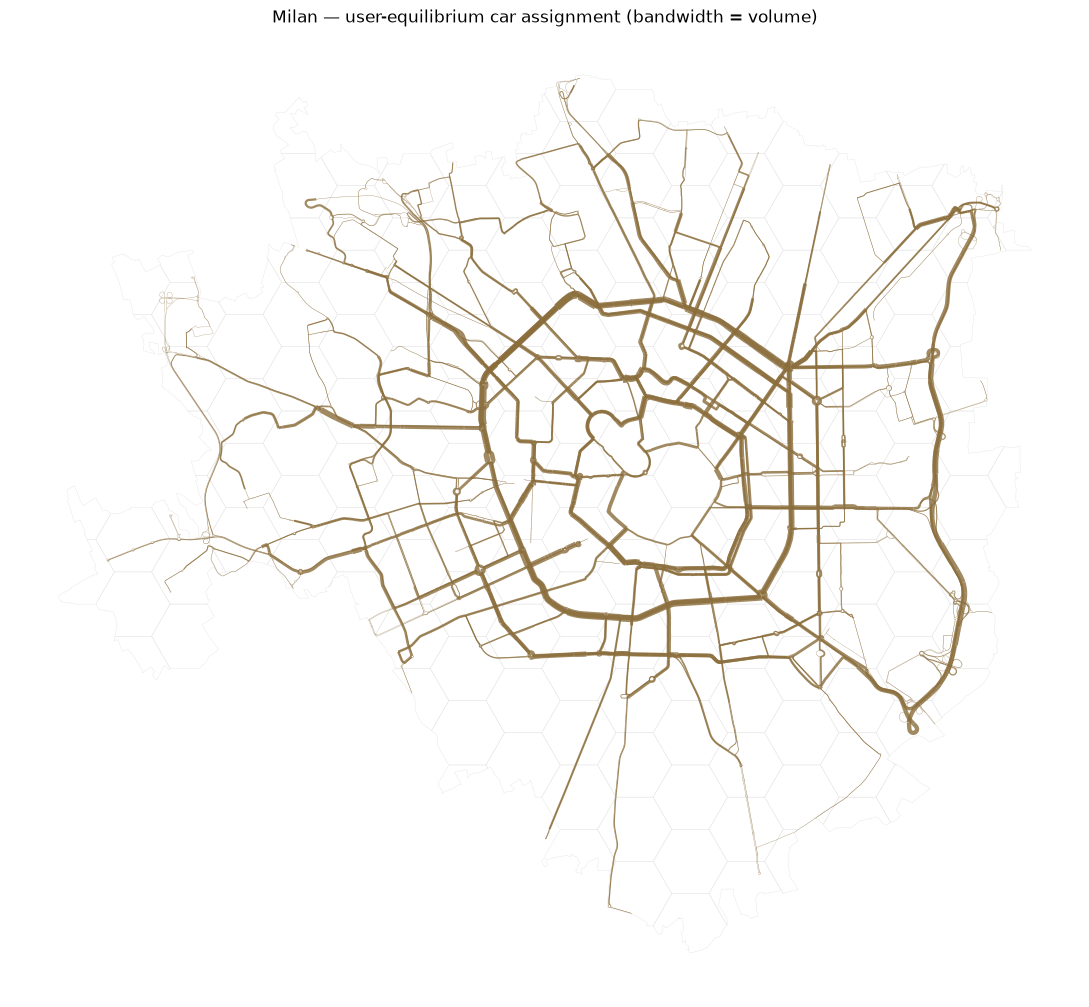

In [18]:
edges_net["flow"] = flow_eq
edges_net["vc"] = vc_eq

fig, ax = plt.subplots(figsize=(11, 11))
grid.boundary.plot(ax=ax, linewidth=0.3, color="#e5e5e5")
loaded = edges_net.sort_values("flow")
w = 0.2 + 6 * loaded["flow"] / max(loaded["flow"].max(), 1)
loaded.plot(ax=ax, linewidth=w, color="#8a6d3b", alpha=0.8)
ax.set_title("Milan — user-equilibrium car assignment (bandwidth = volume)")
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 8. Policy scenario — banning through traffic from the inner cordon

Milan's Area C charges cars entering the historic core; here we test the harder variant:
**cars whose trip neither starts nor ends inside a 2.5 km cordon may not drive through
it**. Trips with an end inside keep full network access. Both demand segments are
assigned to user equilibrium simultaneously (shared congested times), and the difference
map shows where the banned through-trips relocate.

In [19]:
DUOMO = (9.1900, 45.4642)
duomo_xy = gpd.GeoSeries([gpd.points_from_xy([DUOMO[0]], [DUOMO[1]])[0]],
                         crs="EPSG:4326").to_crs(CRS_UTM).iloc[0]
CORDON_M = 2500

mid = np.array([g.interpolate(0.5, normalized=True).coords[0]
                for g in edges_net.geometry])
inside = np.hypot(mid[:, 0] - duomo_xy.x, mid[:, 1] - duomo_xy.y) < CORDON_M
zone_inside = np.hypot(zc[:, 0] - duomo_xy.x, zc[:, 1] - duomo_xy.y) < CORDON_M

through = ~zone_inside[:, None] & ~zone_inside[None, :]      # neither end inside
T_thru = np.where(through, T_asn, 0)
T_rest = np.where(~through, T_asn, 0)
print(f"{int(inside.sum())} links inside the cordon | "
      f"{T_thru.sum():,.0f} through car trips affected "
      f"({T_thru.sum() / T_asn.sum():.1%} of car demand)")

929 links inside the cordon | 43,923 through car trips affected (47.5% of car demand)


In [20]:
BAN = 10_000.0                             # minutes: makes cordon links unusable

def msa_two_class(n_iter=18):
    """MSA with two demand classes: through trips see banned cordon links."""
    v = (aon_assign(e_t0 + BAN * inside, T_thru) + aon_assign(e_t0, T_rest))
    for k in range(2, n_iter + 1):
        t_cong = bpr(e_t0, v, e_cap)
        y = (aon_assign(t_cong + BAN * inside, T_thru)
             + aon_assign(t_cong, T_rest))
        v = v + (y - v) / k
    return v

flow_scn = msa_two_class()
edges_net["flow_scn"] = flow_scn
edges_net["diff"] = edges_net["flow_scn"] - edges_net["flow"]
chg = edges_net.loc[edges_net.flow > 50, "diff"].abs().sum() / 2
print(f"cordon interior volume: {flow_eq[inside].sum():,.0f} -> "
      f"{flow_scn[inside].sum():,.0f} veh "
      f"({1 - flow_scn[inside].sum() / max(flow_eq[inside].sum(), 1):.0%} reduction)")

cordon interior volume: 1,219,220 -> 1,065,850 veh (13% reduction)


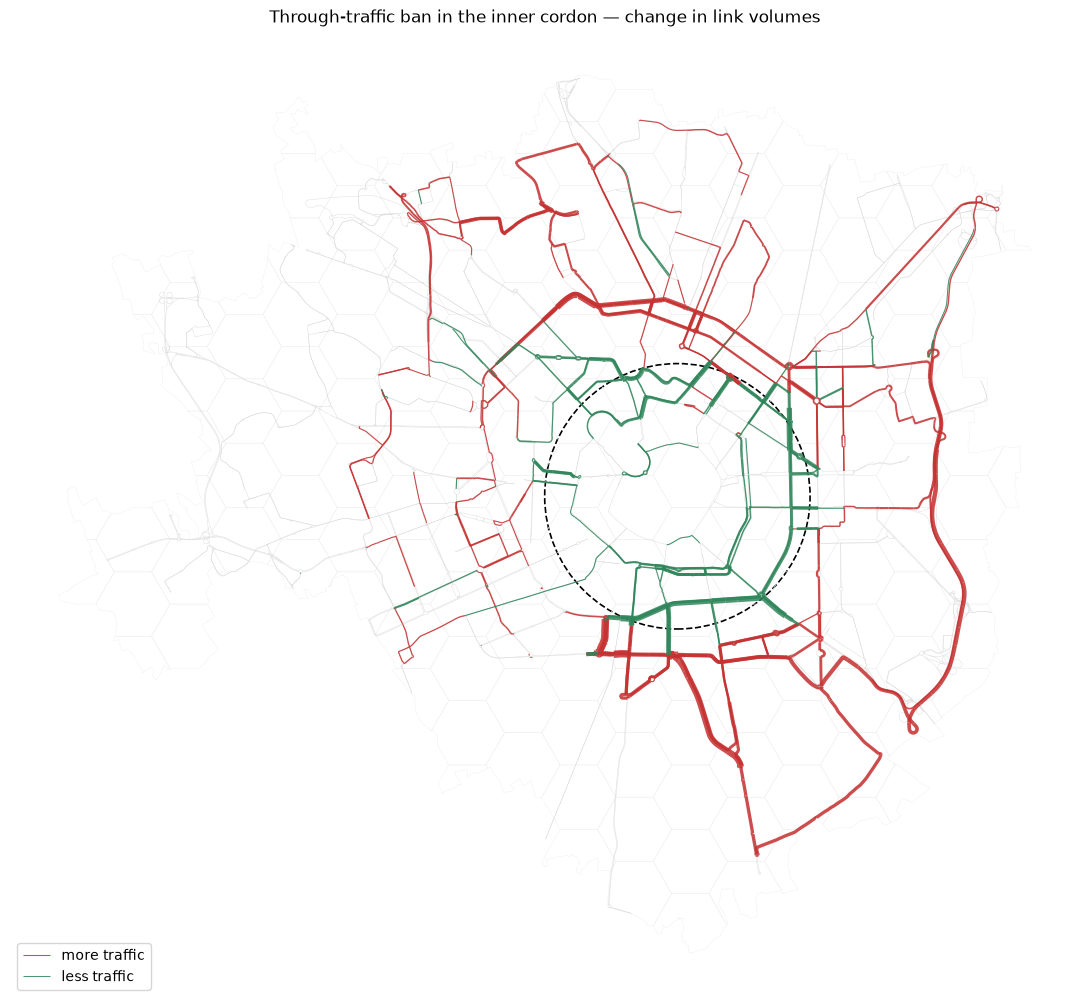

In [21]:
fig, ax = plt.subplots(figsize=(11, 11))
grid.boundary.plot(ax=ax, linewidth=0.3, color="#eeeeee")
edges_net.plot(ax=ax, linewidth=0.3, color="#d9d9d9")
d = edges_net[edges_net["diff"].abs() > 100].sort_values("diff", key=abs)
w = 0.4 + 6 * d["diff"].abs() / max(d["diff"].abs().max(), 1)
d[d["diff"] > 0].plot(ax=ax, linewidth=w[d["diff"] > 0], color="#c53030",
                      alpha=0.85, label="more traffic")
d[d["diff"] < 0].plot(ax=ax, linewidth=w[d["diff"] < 0], color="#2f855a",
                      alpha=0.85, label="less traffic")
circle = plt.Circle((duomo_xy.x, duomo_xy.y), CORDON_M, fill=False,
                    color="black", linestyle="--", linewidth=1.2)
ax.add_patch(circle)
ax.legend(loc="lower left")
ax.set_title("Through-traffic ban in the inner cordon — change in link volumes")
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 9. Select-link analysis

*Who uses this link?* Every OD pair whose equilibrium-time shortest path crosses the
busiest motorway link, re-accumulated and mapped.

In [22]:
study_i = int(np.argmax(np.where(e_cls == "motorway", flow_eq, 0)))
if flow_eq[study_i] == 0:
    study_i = int(np.argmax(flow_eq))
sel_ab = (e_from[study_i], e_to[study_i])

sel_flows = np.zeros(E)
sel_total = 0.0
Dm, Pr = dijkstra(graph_matrix(t_eq), indices=sources, return_predecessors=True)
for i in range(Z):
    pred = Pr[i]
    for j in range(Z):
        f = T_asn[i, j]
        if i == j or f < 1e-6:
            continue
        hops = []
        b = sources[j]
        hit = False
        while b != sources[i]:
            a = pred[b]
            if a < 0:
                break
            hops.append(edge_index[(a, b)])
            if (a, b) == sel_ab:
                hit = True
            b = a
        if hit:
            sel_total += f
            for e in hops:
                sel_flows[e] += f

edges_net["sel_flow"] = sel_flows
print(f"study link carries {flow_eq[study_i]:,.0f} veh at equilibrium; "
      f"{sel_total / T_asn.sum():.1%} of car trips use it")

study link carries 3,298 veh at equilibrium; 3.2% of car trips use it


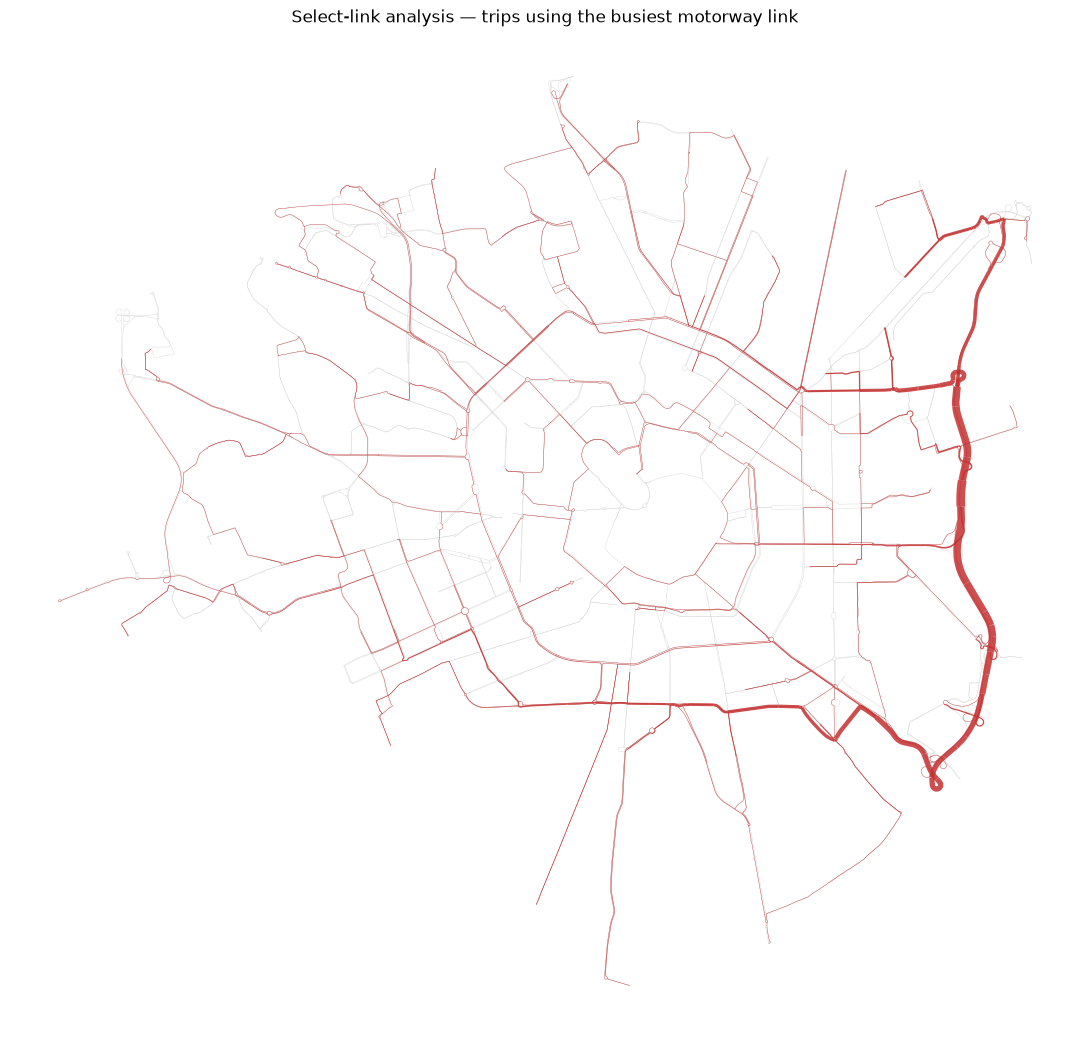

In [23]:
fig, ax = plt.subplots(figsize=(11, 11))
edges_net.plot(ax=ax, linewidth=0.3, color="#d9d9d9")
used = edges_net[edges_net["sel_flow"] > 0].sort_values("sel_flow")
if len(used):
    w = 0.3 + 6 * used["sel_flow"] / used["sel_flow"].max()
    used.plot(ax=ax, linewidth=w, color="#c53030", alpha=0.85)
ax.set_title("Select-link analysis — trips using the busiest motorway link")
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 10. Interactive web maps

Folium exports of the equilibrium loading (colored by v/c) and the scenario difference —
the versions of these maps served at
**[abadeanlou.com/four-step](https://abadeanlou.com/four-step/)** are generated by this
cell.

In [24]:
import folium
from pathlib import Path

Path("outputs/web").mkdir(parents=True, exist_ok=True)

def vc_color(vc):
    return "#2f855a" if vc < 0.5 else "#d69e2e" if vc < 0.9 else "#c53030"

wgs = edges_net.to_crs("EPSG:4326")
wgs["geometry"] = wgs.geometry.simplify(0.0001)
center = [45.4642, 9.19]

m1 = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")
for r in wgs[wgs["flow"] > 200].itertuples():
    folium.PolyLine(
        [(y, x) for x, y in r.geometry.coords],
        weight=1 + 7 * r.flow / wgs["flow"].max(), color=vc_color(r.vc),
        opacity=0.8,
        tooltip=f"{r.cls}: {r.flow:,.0f} veh, v/c {r.vc:.2f}").add_to(m1)
m1.save("outputs/web/equilibrium_map.html")

m2 = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")
dd = wgs[wgs["diff"].abs() > 150]
for r in dd.itertuples():
    folium.PolyLine(
        [(y, x) for x, y in r.geometry.coords],
        weight=1 + 7 * abs(r.diff) / dd["diff"].abs().max(),
        color="#c53030" if r.diff > 0 else "#2f855a", opacity=0.8,
        tooltip=f"{r.diff:+,.0f} veh").add_to(m2)
folium.Circle(center, radius=2500, color="black", weight=2, dash_array="6",
              fill=False, tooltip="through-traffic ban cordon").add_to(m2)
m2.save("outputs/web/scenario_diff_map.html")
print("interactive maps written to outputs/web/")

interactive maps written to outputs/web/


## 11. Exports

In [25]:
from pathlib import Path

out = Path("outputs")
pd.DataFrame(car_skim, index=grid["Z"], columns=grid["Z"]).to_csv(
    out / "car_skim_minutes.csv", float_format="%.2f")
pd.DataFrame(pt_skim, index=grid["Z"], columns=grid["Z"]).to_csv(
    out / "pt_skim_minutes.csv", float_format="%.2f")
edges_net[["cls", "capacity", "flow", "vc", "flow_scn", "diff", "geometry"]] \
    .to_crs("EPSG:4326").to_file(out / "assigned_network.geojson", driver="GeoJSON")
grid[["Z", "population", "jobs", "productions", "attractions", "geometry"]] \
    .to_crs("EPSG:4326").to_file(out / "zones.geojson", driver="GeoJSON")
print("written:", *[p.name for p in out.iterdir() if p.is_file()])

written: assigned_network.geojson car_skim_minutes.csv pt_skim_minutes.csv skim_minutes.csv zones.geojson


## Closing notes

**What carries over unchanged** to a real planning model (I have run this workflow on a
~58,000-link metropolitan network with 2030/2040 scenario attributes): the graph and skim
machinery, gravity calibration, equilibrium loop, and the select-link/scenario tooling.

**What a production model still adds** beyond this notebook:

- **Calibration and validation** — rates, $\beta$, logit coefficients, and BPR parameters
  estimated from surveys; assigned volumes validated against counts.
- **Demand segmentation** — purposes, time periods, car ownership; feedback of congested
  times into distribution and mode choice (the full equilibrium loop).
- **Timetable-based transit assignment** — RAPTOR-style routing and crowding, beyond the
  frequency-based graph used here.
- **Census land use** — replacing the OSM proxies.

*Amirhesam Badeanlou — see also my
[routing engine](https://github.com/abadeanlou/routing-engine-osmnx)
([live](https://abadeanlou.com/routing-engine/)) and
[transit accessibility](https://github.com/abadeanlou/Accessibility-using-Transit)
work ([live maps](https://abadeanlou.com/accessibility/)).*